# HMS - Harmful Brain Activity Classification
## PyTorch Pipeline: nnAudio (Trainable STFT) + EfficientNet + GRU

This notebook implements a full training and inference pipeline that:
1. Loads **raw EEG** signals (no pre-computed spectrograms)
2. Computes spectrograms **on-the-fly** using nnAudio with a trainable STFT
3. Extracts features using a pretrained **EfficientNetV2-B2** backbone
4. Models temporal evolution with a **Bidirectional GRU**
5. Classifies into 6 harmful brain activity categories

### Pipeline
```
Raw EEG [batch, 16, 10000]
    ↓
nnAudio STFT (trainable)
    ↓
Log + Normalize
    ↓
Mono → 3 channel
    ↓
EfficientNet backbone (remove classification head)
    ↓
Pool over frequency, keep time axis
    ↓
GRU reads across time
    ↓
Softmax → 6 classes
```

### Reference
This notebook is the PyTorch counterpart of the Keras starter notebook.
Both can be ensembled at the prediction level (numpy arrays).

# 🛠 | Install Libraries

Run this cell once to install required packages.

In [27]:
# All dependencies are installed via requirements.txt:
#   pip install -r requirements.txt
#
# If running inside the notebook without requirements.txt:
# !pip install -r requirements.txt

# 📚 | Import Libraries

In [28]:
import os
import math
import random
import gc
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from nnAudio.features import STFT

from sklearn.model_selection import StratifiedGroupKFold
import joblib

print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
timm: 1.0.25
CUDA available: True
GPU: Tesla T4


# ⚙️ | Configuration

Mirrors the Keras notebook's CFG class with additions for STFT, GRU,
and differential learning rates.

In [29]:
class CFG:
    # --- General ---
    verbose = 1
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Data ---
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    label2name = dict(enumerate(class_names))
    name2label = {v: k for k, v in label2name.items()}

    # --- EEG ---
    eeg_sample_rate = 200       # Hz
    eeg_duration = 50           # seconds
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 16   # 4 chains x 4 pairs

    # --- nnAudio STFT ---
    n_fft = 128
    hop_length = 128
    trainable_stft = True

    # --- Model ---
    backbone = "tf_efficientnetv2_b2"
    gru_hidden = 128
    gru_layers = 2
    dropout = 0.35

    # --- Training ---
    epochs = 20                 # longer: trainable STFT needs more time
    batch_size = 16
    lr_backbone = 5e-5          # halved: preserve pretrained features better
    lr_stft = 5e-4              # halved: more stable STFT learning
    lr_head = 3e-4              # reduced: steadier convergence
    lr_mode = "cos"
    weight_decay = 1e-4
    max_grad_norm = 1.0
    use_amp = False
    num_workers = 4
    fold = 0
    n_folds = 5

    # --- Labels ---
    use_soft_labels = True      # use expert vote distributions instead of one-hot
    label_smoothing = 0.05      # smooth remaining hard labels

    # --- SpecAugment ---
    spec_freq_mask = 10          # max freq bins to mask
    spec_time_mask = 10          # max time frames to mask
    spec_num_masks = 2          # number of masks per axis

print(f"Device: {CFG.device}")
print(f"Epochs: {CFG.epochs}")
print(f"Soft labels: {CFG.use_soft_labels}")
print(f"Label smoothing: {CFG.label_smoothing}")
print(f"SpecAugment: freq_mask={CFG.spec_freq_mask}, time_mask={CFG.spec_time_mask}")
print(f"LRs: stft={CFG.lr_stft}, backbone={CFG.lr_backbone}, head={CFG.lr_head}")
print(f"STFT: n_fft={CFG.n_fft}, hop_length={CFG.hop_length}")
expected_time_frames = (CFG.eeg_samples - CFG.n_fft) // CFG.hop_length + 1
expected_freq_bins = CFG.n_fft // 2 + 1
print(f"Expected spectrogram shape: [{expected_freq_bins * 4}, {expected_time_frames}]")

Device: cuda
Epochs: 20
Soft labels: True
Label smoothing: 0.05
SpecAugment: freq_mask=10, time_mask=10
LRs: stft=0.0005, backbone=5e-05, head=0.0003
STFT: n_fft=128, hop_length=128
Expected spectrogram shape: [260, 78]


# ♻️ | Reproducibility

Sets value for random seed to produce similar result in each run.

In [30]:
def set_seed(seed=CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# 📁 | Dataset Paths

**Important**: Adjust `BASE_PATH` to match your data location.
The Keras notebook uses `project_root.parent.parent / "data" / "data"`.

In [31]:
project_root = Path.cwd()

# =============================================
# ADJUST THIS PATH TO MATCH YOUR DATA LOCATION
# This matches the Keras notebook's path structure
# =============================================
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

# Output directories
MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify
print("=" * 60)
print(f"Project root: {project_root}")
print(f"Data path:    {BASE_PATH}")
print(f"Data exists:  {BASE_PATH.exists()}")

if BASE_PATH.exists():
    for name in ["train.csv", "test.csv", "train_eegs", "test_eegs"]:
        path = BASE_PATH / name
        status = "✓" if path.exists() else "✗"
        print(f"  {status} {name}")
print("=" * 60)

# Pre-processed bipolar EEG files (.npy)
PROCESSED_DIR = BASE_PATH / "processed" / "bipolar_eegs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Processed EEGs: {PROCESSED_DIR}")


Project root: /home/littl/ECE247A_Final_Project/AL/AL_model
Data path:    /home/littl/data/data
Data exists:  True
  ✓ train.csv
  ✓ test.csv
  ✓ train_eegs
  ✓ test_eegs
Processed EEGs: /home/littl/data/data/processed/bipolar_eegs


# 📖 | Metadata

We only need the EEG paths (not spectrogram paths) since nnAudio
generates spectrograms on-the-fly from raw EEG.

In [32]:
# --- Train ---
df = pd.read_csv(BASE_PATH / "train.csv")
df["eeg_path"] = df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet")
)
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

# Soft labels from expert vote counts
vote_cols = ["seizure_vote", "lpd_vote", "gpd_vote",
             "lrda_vote", "grda_vote", "other_vote"]
if all(c in df.columns for c in vote_cols):
    votes = df[vote_cols].values.astype(np.float32)
    vote_sums = votes.sum(axis=1, keepdims=True)
    vote_sums = np.clip(vote_sums, 1.0, None)  # avoid divide by zero
    df["soft_labels"] = (votes / vote_sums).tolist()
    print(f"✓ Soft labels created from {vote_cols}")
    print(f"  Example: {df['soft_labels'].iloc[0]}")
else:
    df["soft_labels"] = None
    print("⚠ Vote columns not found — will use one-hot labels")

print(f"Train CSV rows: {len(df)}")
print(f"Unique EEG files: {df['eeg_id'].nunique()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
display(df.head(2))

# --- Test ---
test_df = pd.read_csv(BASE_PATH / "test.csv")
test_df["eeg_path"] = test_df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet")
)

print(f"\nTest CSV rows: {len(test_df)}")
display(test_df.head(2))

✓ Soft labels created from ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
  Example: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Train CSV rows: 106800
Unique EEG files: 17089
Unique patients: 1950


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_path,class_name,class_label,soft_labels
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"



Test CSV rows: 1


,spectrogram_id,eeg_id,patient_id,eeg_path
0,853520,3911565283,6885,/home/littl/data/data/test_eegs/3911565283.par...


# 🧠 | Bipolar Banana Montage

The standard 10-20 system has 19 electrodes. We compute the **double banana bipolar montage**,
which subtracts adjacent electrodes to produce 16 bipolar channels in 4 chains:

| Chain | Pairs | Region |
|-------|-------|--------|
| LL (Left Lateral) | Fp1-F7, F7-T3, T3-T5, T5-O1 | Left temporal |
| RL (Right Lateral) | Fp2-F8, F8-T4, T4-T6, T6-O2 | Right temporal |
| LP (Left Parasagittal) | Fp1-F3, F3-C3, C3-P3, P3-O1 | Left central |
| RP (Right Parasagittal) | Fp2-F4, F4-C4, C4-P4, P4-O2 | Right central |

In [33]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1", "F7"), ("F7", "T3"), ("T3", "T5"), ("T5", "O1")],
    "RL": [("Fp2", "F8"), ("F8", "T4"), ("T4", "T6"), ("T6", "O2")],
    "LP": [("Fp1", "F3"), ("F3", "C3"), ("C3", "P3"), ("P3", "O1")],
    "RP": [("Fp2", "F4"), ("F4", "C4"), ("C4", "P4"), ("P4", "O2")],
}

BIPOLAR_PAIRS = []
CHAIN_ORDER = ["LL", "RL", "LP", "RP"]
for chain_name in CHAIN_ORDER:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain_name])

print(f"Total bipolar channels: {len(BIPOLAR_PAIRS)}")
for i, (a, b) in enumerate(BIPOLAR_PAIRS):
    chain = CHAIN_ORDER[i // 4]
    print(f"  Ch {i:2d} ({chain}): {a} - {b}")

# Verify electrode names exist in an actual EEG file
sample_eeg = pd.read_parquet(df.iloc[0]["eeg_path"])
eeg_columns = sample_eeg.columns.tolist()
print(f"\nEEG file columns: {eeg_columns}")
needed = set()
for a, b in BIPOLAR_PAIRS:
    needed.add(a)
    needed.add(b)
missing = needed - set(eeg_columns)
if missing:
    print(f"⚠ WARNING: Missing electrodes: {missing}")
    print("You may need to adjust electrode names in BIPOLAR_MONTAGE")
else:
    print("✓ All required electrodes found in EEG data")

Total bipolar channels: 16
  Ch  0 (LL): Fp1 - F7
  Ch  1 (LL): F7 - T3
  Ch  2 (LL): T3 - T5
  Ch  3 (LL): T5 - O1
  Ch  4 (RL): Fp2 - F8
  Ch  5 (RL): F8 - T4
  Ch  6 (RL): T4 - T6
  Ch  7 (RL): T6 - O2
  Ch  8 (LP): Fp1 - F3
  Ch  9 (LP): F3 - C3
  Ch 10 (LP): C3 - P3
  Ch 11 (LP): P3 - O1
  Ch 12 (RP): Fp2 - F4
  Ch 13 (RP): F4 - C4
  Ch 14 (RP): C4 - P4
  Ch 15 (RP): P4 - O2

EEG file columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']
✓ All required electrodes found in EEG data


# 🔄 | Pre-process EEG → Bipolar .npz

One-time conversion: read each raw EEG parquet, compute bipolar montage,
normalize, and save as a lightweight `.npz` file.

Each file contains:
- `eeg`: normalized bipolar signal `[16, 10000]`
- `stats`: raw channel statistics `[32]` (16 means + 16 stds)

**Why save stats?** Normalization destroys amplitude information.
A seizure channel has high std, suppression has low std.
We preserve these as side features for the classification head.

In [34]:
def preprocess_eeg(row_idx, dataframe, split="train"):
    """Convert one EEG parquet → pre-processed bipolar .npz file.
    Saves both normalized EEG [16, 10000] and raw channel stats [32].
    """
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npz"

    if output_path.exists():
        return  # skip if already done

    # Load raw EEG
    eeg_df = pd.read_parquet(row["eeg_path"])

    # Extract window
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    # Pad if needed
    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(
            np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
            columns=window.columns,
        )
        window = pd.concat([window, pad], ignore_index=True)

    # Compute bipolar montage
    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        if a in cols and b in cols:
            sig = window[a].values - window[b].values
        else:
            sig = np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)  # [16, 10000]

    # Clean
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)

    # Compute stats BEFORE normalizing (this is what normalization destroys)
    chan_mean = bipolar.mean(axis=1).astype(np.float32)  # [16]
    chan_std = bipolar.std(axis=1).astype(np.float32)    # [16]
    stats = np.concatenate([chan_mean, chan_std])          # [32]

    # Normalize per channel
    bipolar = (bipolar - chan_mean[:, None]) / (chan_std[:, None] + 1e-6)

    # Save both: normalized EEG + raw stats
    np.savez_compressed(str(output_path), eeg=bipolar, stats=stats)


# --- Process training EEGs ---
unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
print(f"Processing {len(unique_train)} unique training EEG files...")
_ = joblib.Parallel(n_jobs=-1, backend="loky")(
    joblib.delayed(preprocess_eeg)(i, unique_train, "train")
    for i in tqdm(range(len(unique_train)))
)

# --- Process test EEGs ---
print(f"Processing {len(test_df)} test EEG files...")
_ = joblib.Parallel(n_jobs=-1, backend="loky")(
    joblib.delayed(preprocess_eeg)(i, test_df, "test")
    for i in tqdm(range(len(test_df)))
)

sample_file = list(PROCESSED_DIR.glob('*.npz'))[0]
sample_data = np.load(str(sample_file))
print(f"\n✓ Pre-processing complete. Files saved to: {PROCESSED_DIR}")
print(f"  Sample file size: {sample_file.stat().st_size / 1024:.0f} KB")
print(f"  EEG shape: {sample_data['eeg'].shape}")
print(f"  Stats shape: {sample_data['stats'].shape}  (16 means + 16 stds)")

Processing 17089 unique training EEG files...


  0%|          | 0/17089 [00:00<?, ?it/s]

Processing 1 test EEG files...


  0%|          | 0/1 [00:00<?, ?it/s]


✓ Pre-processing complete. Files saved to: /home/littl/data/data/processed/bipolar_eegs
  Sample file size: 529 KB
  EEG shape: (16, 10000)
  Stats shape: (32,)  (16 means + 16 stds)


# 🍚 | PyTorch Dataset (Fast .npy Loading)

Loads pre-processed bipolar `.npy` files — no parquet parsing, no cache bloat.
Each `__getitem__` call is a single `np.load()` (~0.5 ms vs ~50 ms for parquet).

**No spectrogram here** — nnAudio computes that inside the model on GPU.

In [35]:
class HMSDataset(Dataset):
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        self.npz_paths = [
            str(PROCESSED_DIR / f"{eid}.npz")
            for eid in self.df["eeg_id"].values
        ]

    def __len__(self):
        return len(self.df)

    def _augment_eeg(self, eeg):
        """Augmentations on normalized EEG signal."""
        noise_std = np.random.uniform(0.005, 0.015)
        eeg = eeg + np.random.normal(0, noise_std, eeg.shape).astype(np.float32)
        scale = np.random.uniform(0.8, 1.2)
        eeg = eeg * scale
        if random.random() < 0.3:
            n_drop = random.randint(1, 2)
            drop_idx = random.sample(range(16), n_drop)
            eeg[drop_idx] = 0.0
        return eeg

    def _get_label(self, idx):
        """
        Get label for sample. Priority:
        1. Soft labels from expert votes (real probability distribution)
        2. One-hot with label smoothing (fallback)
        """
        row = self.df.iloc[idx]

        # Soft labels from vote counts
        if CFG.use_soft_labels and row.get("soft_labels") is not None:
            label = np.array(row["soft_labels"], dtype=np.float32)
            return torch.tensor(label, dtype=torch.float32)

        # Fallback: one-hot with label smoothing
        label = torch.zeros(CFG.num_classes, dtype=torch.float32)
        label[int(row["class_label"])] = 1.0

        if CFG.label_smoothing > 0:
            label = label * (1 - CFG.label_smoothing) + CFG.label_smoothing / CFG.num_classes

        return label

    def __getitem__(self, idx):
        data = np.load(self.npz_paths[idx])
        eeg = data["eeg"]        # [16, 10000] normalized
        stats = data["stats"]    # [32] raw channel means + stds

        if self.augment:
            eeg = self._augment_eeg(eeg)

        eeg_tensor = torch.tensor(eeg, dtype=torch.float32)
        stats_tensor = torch.tensor(stats, dtype=torch.float32)

        if self.mode == "test":
            return eeg_tensor, stats_tensor

        label = self._get_label(idx)
        return eeg_tensor, stats_tensor, label

## MixUp Augmentation

The Keras notebook applies MixUp via `keras_cv.layers.MixUp(alpha=2.0)` on every batch.
Here's the PyTorch equivalent, applied during training.

In [36]:
def mixup(eeg, stats, targets, alpha=2.0):
    """
    MixUp augmentation — blends pairs of samples, stats, and labels.
    Equivalent to keras_cv.layers.MixUp(alpha=2.0).
    """
    indices = torch.randperm(eeg.size(0), device=eeg.device)
    lam = torch.distributions.Beta(alpha, alpha).sample().to(eeg.device)
    mixed_eeg = lam * eeg + (1 - lam) * eeg[indices]
    mixed_stats = lam * stats + (1 - lam) * stats[indices]
    mixed_targets = lam * targets + (1 - lam) * targets[indices]
    return mixed_eeg, mixed_stats, mixed_targets

# 🤖 | Model Architecture

4 components:
1. **nnAudio STFT**: Raw EEG → spectrogram (trainable, on GPU)
2. **EfficientNetV2-B2**: Feature extraction (pretrained ImageNet, same as Keras preset)
3. **Frequency pooling**: Collapse frequency axis, preserve time axis
4. **Bidirectional GRU**: Model temporal evolution → classify

In [37]:
class SpectrogramModel(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        # ==============================================================
        # Stage 1: nnAudio STFT — raw EEG → spectrogram on GPU
        # ==============================================================
        self.stft = STFT(
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            sr=cfg.eeg_sample_rate,
            trainable=cfg.trainable_stft,
            output_format="Magnitude",
        )
        self.log_eps = 1e-6

        # ==============================================================
        # Stage 2: CNN backbone
        # ==============================================================
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained=True,
            in_chans=3,
            features_only=True,
        )
        with torch.no_grad():
            dummy = torch.randn(1, 3, 64, 64)
            backbone_out = self.backbone(dummy)
        backbone_channels = backbone_out[-1].shape[1]
        print(f"Backbone output channels: {backbone_channels}")

        # ==============================================================
        # Stage 3: GRU — reads CNN features across time
        # ==============================================================
        self.gru = nn.GRU(
            input_size=backbone_channels,
            hidden_size=cfg.gru_hidden,
            num_layers=cfg.gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=cfg.dropout if cfg.gru_layers > 1 else 0.0,
        )

        # ==============================================================
        # Stage 4: Stats side branch
        # ==============================================================
        self.stats_mlp = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(64, 32),
        )

        # ==============================================================
        # Stage 5: Classification head (GRU output + stats features)
        # ==============================================================
        gru_out_dim = cfg.gru_hidden * 2  # bidirectional
        self.head = nn.Sequential(
            nn.Dropout(cfg.dropout),
            nn.Linear(gru_out_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(128, cfg.num_classes),
        )

    def make_spectrograms(self, eeg):
        """Raw EEG → 4-chain spectrogram, cropped to 0-30 Hz."""
        batch, channels, time = eeg.shape
        x = eeg.reshape(batch * channels, time)
        x = self.stft(x)
        freq_bins, time_frames = x.shape[1], x.shape[2]
        x = x.reshape(batch, channels, freq_bins, time_frames)
        max_bin = int(30 / (self.cfg.eeg_sample_rate / self.cfg.n_fft)) + 1
        ll = x[:, 0:4, :max_bin, :].mean(dim=1)
        rl = x[:, 4:8, :max_bin, :].mean(dim=1)
        lp = x[:, 8:12, :max_bin, :].mean(dim=1)
        rp = x[:, 12:16, :max_bin, :].mean(dim=1)
        return torch.cat([ll, rl, lp, rp], dim=1)

    def spec_augment(self, spec):
        """
        SpecAugment: mask random frequency and time bands.
        Equivalent to Keras notebook's RandomCutout.
        Applied only during training.
        Input/Output: [batch, freq, time]
        """
        if not self.training:
            return spec

        batch, freq, time = spec.shape

        for _ in range(self.cfg.spec_num_masks):
            # Frequency masking
            f = random.randint(0, self.cfg.spec_freq_mask)
            f0 = random.randint(0, max(freq - f, 1))
            spec[:, f0:f0+f, :] = 0

            # Time masking
            t = random.randint(0, self.cfg.spec_time_mask)
            t0 = random.randint(0, max(time - t, 1))
            spec[:, :, t0:t0+t] = 0

        return spec

    def process_spectrogram(self, spec):
        """Log + normalize + SpecAugment + 3-channel."""
        x = torch.log(spec.clamp(min=self.log_eps))
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True) + 1e-6
        x = (x - mean) / std

        # SpecAugment after normalization (only during training)
        x = self.spec_augment(x)

        return x.unsqueeze(1).repeat(1, 3, 1, 1)

    def forward(self, eeg, stats):
        """
        Full pipeline: raw EEG + stats → class probabilities.
        Input:  eeg   [batch, 16, 10000]
                stats [batch, 32]
        Output: probs [batch, 6]
        """
        # Main path: EEG → STFT → SpecAugment → CNN → GRU
        spec = self.make_spectrograms(eeg)
        img = self.process_spectrogram(spec)
        features = self.backbone(img)
        fmap = features[-1]
        x = fmap.mean(dim=2)
        x = x.permute(0, 2, 1)
        x = x.float()
        x, _ = self.gru(x)
        x = x[:, -1, :]

        # Side path: stats → MLP
        s = self.stats_mlp(stats.float())

        # Combine and classify
        combined = torch.cat([x, s], dim=1)
        logits = self.head(combined)
        return F.softmax(logits, dim=1)

## Model Sanity Check

Verify shapes at each stage with dummy data.

In [38]:
# Sanity check on CPU only — no GPU memory used
model_cpu = SpectrogramModel(CFG)  # stays on CPU

dummy_eeg = torch.randn(2, CFG.num_bipolar_channels, CFG.eeg_samples)
dummy_stats = torch.randn(2, 32)
with torch.no_grad():
    spec = model_cpu.make_spectrograms(dummy_eeg)
    print(f"After STFT:          {spec.shape}")
    img = model_cpu.process_spectrogram(spec)
    print(f"After log+norm+3ch:  {img.shape}")
    feats = model_cpu.backbone(img)
    print(f"After CNN backbone:  {feats[-1].shape}")
    pooled = feats[-1].mean(dim=2)
    print(f"After freq pooling:  {pooled.shape}")
    out = model_cpu(dummy_eeg, dummy_stats)
    print(f"Final output:        {out.shape}")
    print(f"Prob sum (expect 1): {out.sum(dim=1).numpy()}")

total_params = sum(p.numel() for p in model_cpu.parameters())
train_params = sum(p.numel() for p in model_cpu.parameters() if p.requires_grad)
model_size_mb = sum(p.numel() * p.element_size() for p in model_cpu.parameters()) / 1e6
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {train_params:,}")
print(f"Model size:       {model_size_mb:.1f} MB")

del model_cpu, dummy_eeg, dummy_stats, spec, img, feats, pooled, out
gc.collect()

STFT kernels created, time used = 0.0028 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 208
After STFT:          torch.Size([2, 80, 79])
After log+norm+3ch:  torch.Size([2, 3, 80, 79])
After CNN backbone:  torch.Size([2, 208, 3, 3])
After freq pooling:  torch.Size([2, 208, 3])
Final output:        torch.Size([2, 6])
Prob sum (expect 1): [1. 1.]

Total params:     9,006,036
Trainable params: 9,006,036
Model size:       36.0 MB


0

# 🔪 | Data Split

**Identical to Keras notebook**: `StratifiedGroupKFold` with 5 folds,
grouped by `patient_id` to prevent leakage, stratified by `class_label`.

In [39]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

df["fold"] = -1
df.reset_index(drop=True, inplace=True)
for fold, (train_idx, valid_idx) in enumerate(
    sgkf.split(df, y=df["class_label"], groups=df["patient_id"])
):
    df.loc[valid_idx, "fold"] = fold

print("Samples per fold and class:")
display(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Samples per fold and class:


eeg_id                                
class_name    GPD  GRDA   LPD  LRDA Other Seizure
fold                                             
0            2050  2605  1168  3793  3462    4007
1            4832  4856  4463  3117  3851    4383
2            5386  3389  2658  2432  3598    3711
3            2545  4311  2318  4296  3884    4787
4            1889  3700  4249  3002  4013    4045

## Build Train & Validation Sets

Same sampling strategy as Keras notebook: one row per `spectrogram_id`.

In [40]:
sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
train_df = sample_df[sample_df.fold != CFG.fold].reset_index(drop=True)
valid_df = sample_df[sample_df.fold == CFG.fold].reset_index(drop=True)
print(f"# Num Train: {len(train_df)} | Num Valid: {len(valid_df)}")

# Datasets
train_dataset = HMSDataset(train_df, mode="train", augment=True)
valid_dataset = HMSDataset(valid_df, mode="valid", augment=False)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=True,              # same as Keras drop_remainder=True
    persistent_workers=True if CFG.num_workers > 0 else False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True if CFG.num_workers > 0 else False,
)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

# Num Train: 9166 | Num Valid: 1972
Train batches: 572 | Valid batches: 124


## Dataset Sanity Check

EEG batch:   torch.Size([16, 16, 10000])
Stats batch: torch.Size([16, 32])
Label batch: torch.Size([16, 6])

Stats sample (first 16 = means, last 16 = stds):
  Means range: [-17.22, 36.25]
  Stds range:  [31.36, 364.16]


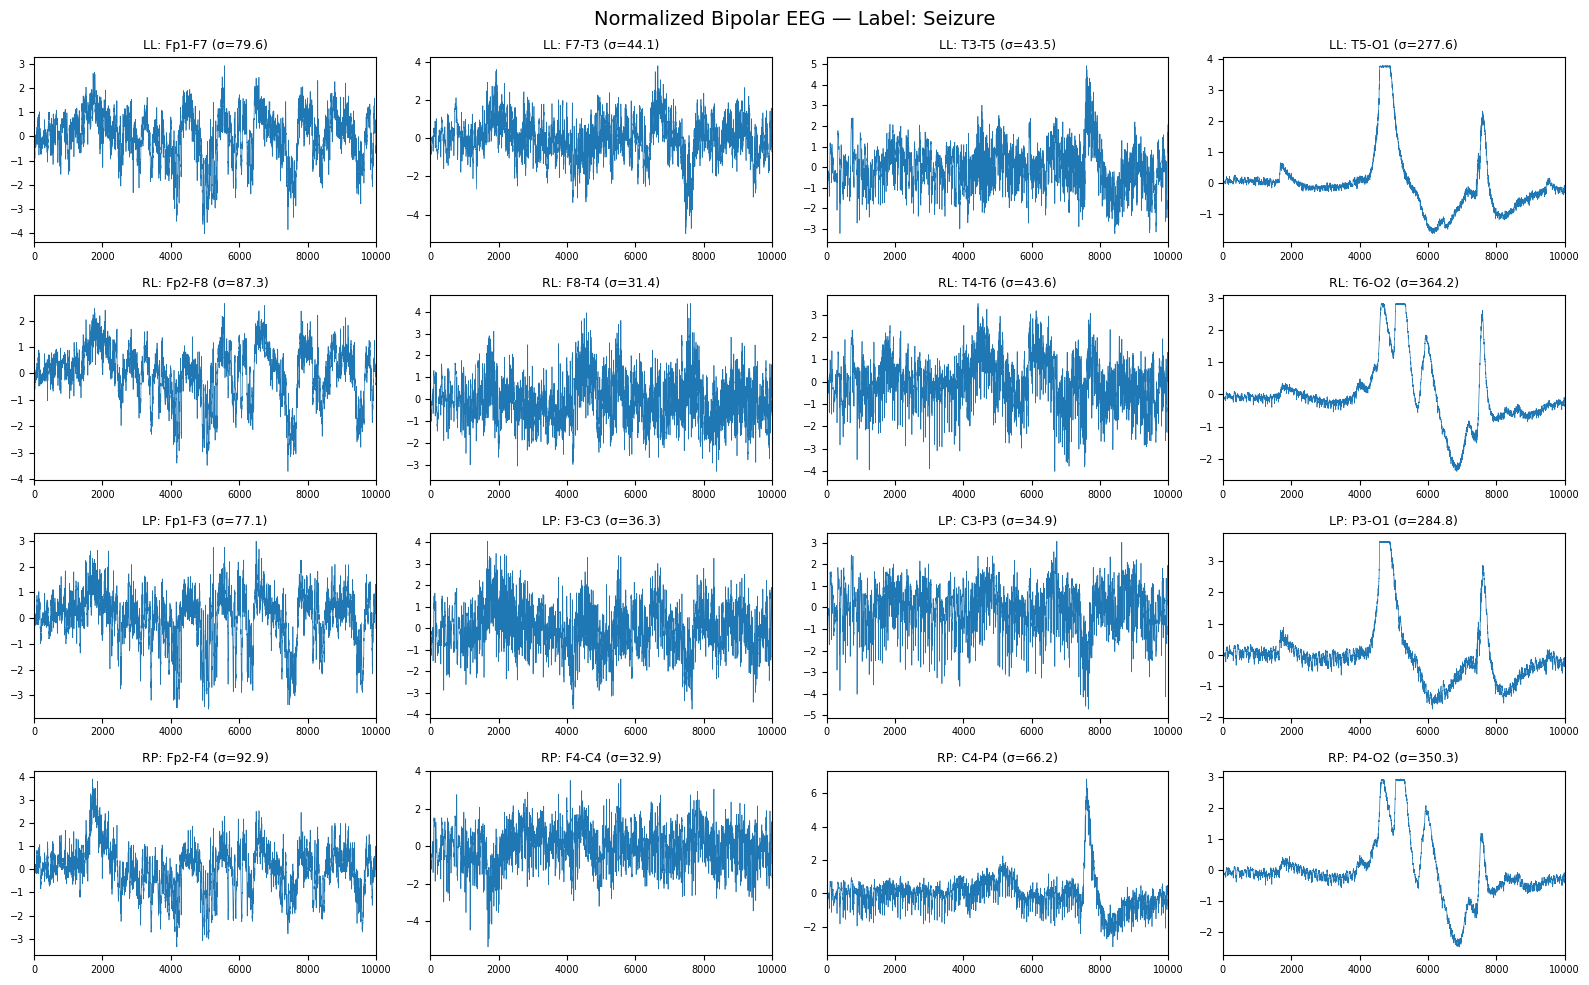

In [41]:
sample_eeg, sample_stats, sample_label = next(iter(train_loader))
print(f"EEG batch:   {sample_eeg.shape}")      # [batch, 16, 10000]
print(f"Stats batch: {sample_stats.shape}")     # [batch, 32]
print(f"Label batch: {sample_label.shape}")     # [batch, 6]
print(f"\nStats sample (first 16 = means, last 16 = stds):")
print(f"  Means range: [{sample_stats[0,:16].min():.2f}, {sample_stats[0,:16].max():.2f}]")
print(f"  Stds range:  [{sample_stats[0,16:].min():.2f}, {sample_stats[0,16:].max():.2f}]")

# Plot raw EEG channels for first sample
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
eeg_np = sample_eeg[0].numpy()
label_name = CFG.label2name[sample_label[0].argmax().item()]

for i in range(16):
    ax = axes[i // 4][i % 4]
    ax.plot(eeg_np[i], linewidth=0.5)
    chain = CHAIN_ORDER[i // 4]
    pair = BIPOLAR_PAIRS[i]
    std_val = sample_stats[0, 16 + i].item()  # show raw std in title
    ax.set_title(f"{chain}: {pair[0]}-{pair[1]} (σ={std_val:.1f})", fontsize=9)
    ax.set_xlim(0, CFG.eeg_samples)
    ax.tick_params(labelsize=7)

fig.suptitle(f"Normalized Bipolar EEG — Label: {label_name}", fontsize=14)
plt.tight_layout()
plt.show()

# 🔍 | Loss Function

KL Divergence — same as `keras.losses.KLDivergence()` in the Keras notebook.

In [42]:
class KLDivLoss(nn.Module):
    """
    KL Divergence loss.
    PyTorch KLDivLoss expects log-probabilities, so we log() our softmax output.
    """
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="batchmean")

    def forward(self, preds, targets):
        return self.loss_fn(torch.log(preds.clamp(min=1e-8)), targets)

criterion = KLDivLoss()

# ⚓ | Optimizer & LR Schedule

**Differential learning rates** — the Keras notebook uses a single LR for everything.
Here we use separate rates because our model has components at different training maturity:
- STFT: learning from scratch → highest LR
- Backbone: pretrained ImageNet → lowest LR
- GRU + head: new layers → medium LR

The schedule shape matches the Keras notebook: linear warmup → cosine decay.

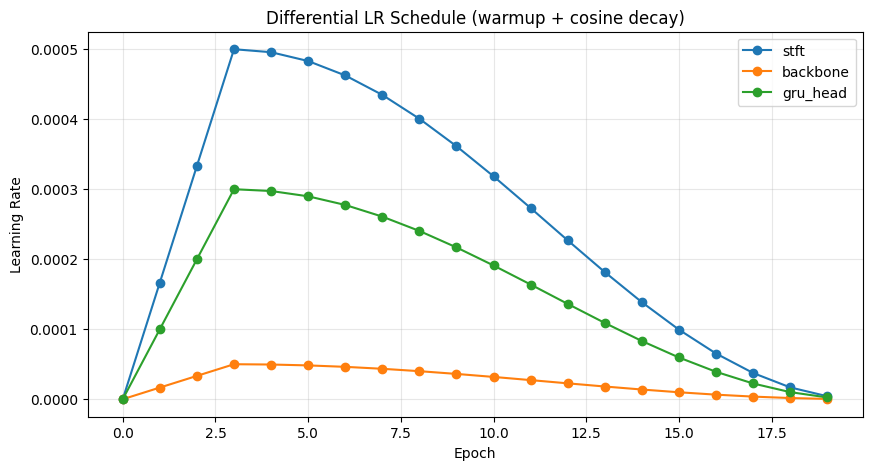

In [43]:
def build_optimizer(model, cfg=CFG):
    """AdamW with differential learning rates per component."""
    return torch.optim.AdamW([
        {"params": model.stft.parameters(), "lr": cfg.lr_stft, "name": "stft"},
        {"params": model.backbone.parameters(), "lr": cfg.lr_backbone, "name": "backbone"},
        {"params": list(model.gru.parameters())
                 + list(model.stats_mlp.parameters())
                 + list(model.head.parameters()),
         "lr": cfg.lr_head, "name": "gru_head"},
    ], weight_decay=cfg.weight_decay)


def get_cosine_schedule(optimizer, epochs, warmup_epochs=3):
    """Cosine annealing with linear warmup."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# --- Visualize LR schedule (no model needed, just compute the math) ---
lr_names = ["stft", "backbone", "gru_head"]
lr_bases = [CFG.lr_stft, CFG.lr_backbone, CFG.lr_head]
warmup_epochs = 3

def lr_lambda_viz(epoch):
    if epoch < warmup_epochs:
        return epoch / warmup_epochs
    progress = (epoch - warmup_epochs) / (CFG.epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

plt.figure(figsize=(10, 5))
for name, base_lr in zip(lr_names, lr_bases):
    lrs = [base_lr * lr_lambda_viz(e) for e in range(CFG.epochs)]
    plt.plot(lrs, marker="o", label=name)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Differential LR Schedule (warmup + cosine decay)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 🚂 | Training & Validation Functions

Includes:
- **Mixed precision** (`autocast` + `GradScaler`) — PyTorch equivalent of Keras `mixed_float16`
- **MixUp** on every training batch — matches Keras notebook's always-on augmentation
- **Gradient clipping** — essential for GRU stability

In [44]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, cfg=CFG):
    """Train one epoch with MixUp and stats side features."""
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch+1}/{cfg.epochs}")
    for eeg, stats, labels in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # MixUp all three tensors together
        eeg, stats, labels = mixup(eeg, stats, labels, alpha=2.0)

        # Forward
        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels)

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        num_batches += 1

        gpu_gb = torch.cuda.memory_allocated() / 1e9
        pbar.set_postfix({
            "loss": f"{running_loss / num_batches:.4f}",
            "gpu": f"{gpu_gb:.1f}GB"
        })

    return running_loss / num_batches


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, cfg=CFG):
    """Validate one epoch."""
    model.eval()
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Valid Epoch {epoch+1}/{cfg.epochs}")
    for eeg, stats, labels in pbar:
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg, stats)
            loss = criterion(preds, labels)

        running_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({"val_loss": f"{running_loss / num_batches:.4f}"})

    return running_loss / num_batches

# 🏋️ | Training Loop

Equivalent to Keras notebook's `model.fit()` with `ModelCheckpoint` callback.

## Training

The model is created **once** here and moved to GPU. A single test
forward+backward pass verifies GPU fit before the full training loop.
If OOM occurs, the `except` block cleans up and prints suggested fixes.

In [45]:
# ============================================================
# This is the ONLY cell that puts a model on GPU.
# If you hit OOM: Kernel → Restart, then reduce batch_size.
# ============================================================
gc.collect()
torch.cuda.empty_cache()
print(f"GPU before init: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Initialize
model = SpectrogramModel(CFG).to(CFG.device)
optimizer = build_optimizer(model, CFG)
scheduler = get_cosine_schedule(optimizer, CFG.epochs)
print(f"GPU after model: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# --- Quick GPU fit test ---
print("\nTesting forward+backward...")
model.train()
torch.cuda.reset_peak_memory_stats()
try:
    _eeg = torch.randn(CFG.batch_size, CFG.num_bipolar_channels, CFG.eeg_samples).to(CFG.device)
    _stats = torch.randn(CFG.batch_size, 32).to(CFG.device)
    _labels = torch.randn(CFG.batch_size, CFG.num_classes).softmax(dim=1).to(CFG.device)
    _preds = model(_eeg, _stats)
    _loss = criterion(_preds, _labels)
    _loss.backward()
    model.zero_grad()
    peak = torch.cuda.max_memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✓ GPU fit test passed: {peak:.2f} GB / {total:.2f} GB ({peak/total*100:.0f}%)")
    if peak / total > 0.85:
        print("  ⚠ Tight — consider reducing batch_size")
    del _eeg, _stats, _labels, _preds, _loss
    gc.collect()
    torch.cuda.empty_cache()
except RuntimeError as e:
    print(f"✗ OOM on test batch. Restart kernel and reduce:")
    print(f"  CFG.batch_size = {CFG.batch_size // 2}")
    raise  # stop here, don't start training

# --- Training loop ---
best_val_loss = float("inf")
best_epoch = -1
history = {"train_loss": [], "val_loss": [], "lr": []}
checkpoint_path = str(MODELS_DIR / f"best_model_fold{CFG.fold}.pt")

print(f"\nTraining fold {CFG.fold} for {CFG.epochs} epochs")
print(f"Checkpoint: {checkpoint_path}")
print("=" * 60)

try:
    for epoch in range(CFG.epochs):
        current_lrs = {pg["name"]: f"{pg['lr']:.2e}" for pg in optimizer.param_groups}
        print(f"\nEpoch {epoch+1}/{CFG.epochs} | LRs: {current_lrs}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, CFG.device, epoch
        )
        val_loss = validate(
            model, valid_loader, criterion, CFG.device, epoch
        )
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(optimizer.param_groups[1]["lr"])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_loss": val_loss,
            }, checkpoint_path)
            print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")
        else:
            print(f"  val_loss: {val_loss:.4f} (best: {best_val_loss:.4f} @ epoch {best_epoch+1})")

except RuntimeError as e:
    print(f"\n✗ Training failed: {e}")
    if "out of memory" in str(e).lower():
        print("  → Restart kernel, reduce batch_size or n_fft")

finally:
    gc.collect()
    torch.cuda.empty_cache()
    print(f"\nGPU after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

if best_epoch >= 0:
    print("\n" + "=" * 60)
    print(f"Done. Best val_loss: {best_val_loss:.4f} at epoch {best_epoch+1}")

GPU before init: 0.27 GB
STFT kernels created, time used = 0.0022 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone output channels: 208
GPU after model: 0.16 GB

Testing forward+backward...
✓ GPU fit test passed: 0.44 GB / 15.64 GB (3%)

Training fold 0 for 20 epochs
Checkpoint: /home/littl/ECE247A_Final_Project/AL/AL_model/models/best_model_fold0.pt

Epoch 1/20 | LRs: {'stft': '0.00e+00', 'backbone': '0.00e+00', 'gru_head': '0.00e+00'}


/var/tmp/ipykernel_401651/3196089896.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.use_amp)


Train Epoch 1/20:   0%|          | 0/572 [00:00<?, ?it/s]

...

Valid Epoch 19/20:   0%|          | 0/124 [00:00<?, ?it/s]

  val_loss: 0.7966 (best: 0.7913 @ epoch 16)

Epoch 20/20 | LRs: {'stft': '4.26e-06', 'backbone': '4.26e-07', 'gru_head': '2.55e-06'}


Train Epoch 20/20:   0%|          | 0/572 [00:00<?, ?it/s]

Valid Epoch 20/20:   0%|          | 0/124 [00:00<?, ?it/s]

  val_loss: 0.7982 (best: 0.7913 @ epoch 16)

GPU after cleanup: 0.27 GB

Done. Best val_loss: 0.7913 at epoch 16


## Training History

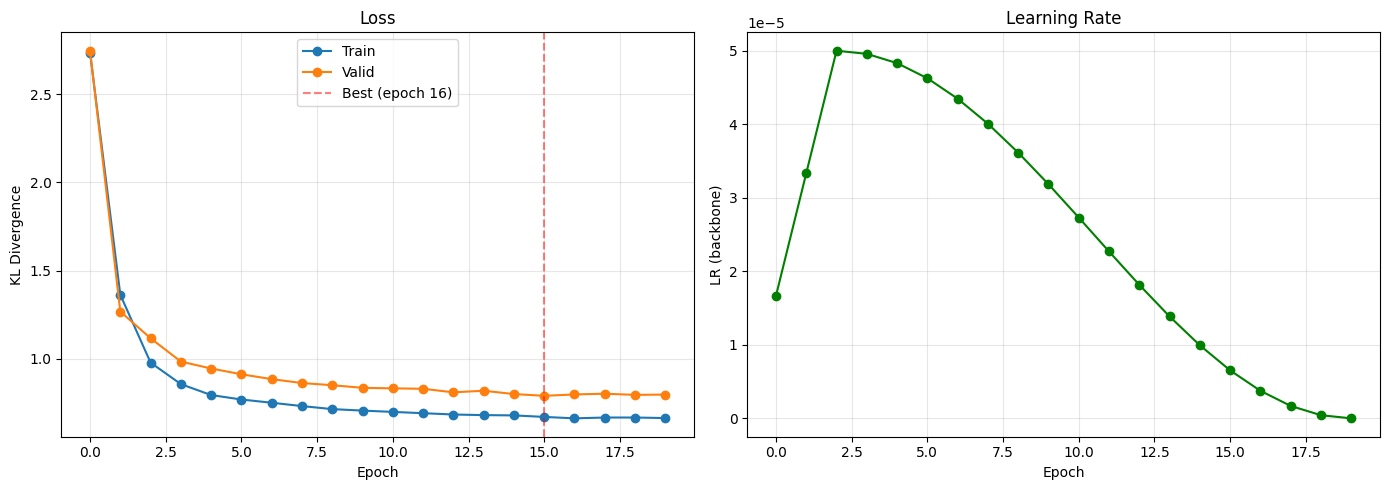

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train", marker="o")
ax1.plot(history["val_loss"], label="Valid", marker="o")
ax1.axvline(best_epoch, color="r", ls="--", alpha=0.5, label=f"Best (epoch {best_epoch+1})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("KL Divergence")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["lr"], marker="o", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("LR (backbone)")
ax2.set_title("Learning Rate")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🧪 | Prediction

## Load Best Model

In [47]:
checkpoint = torch.load(checkpoint_path, map_location=CFG.device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  val_loss: {checkpoint['val_loss']:.4f}")

✓ Loaded best model from epoch 16
  val_loss: 0.7913


## Build Test Dataset

In [48]:
test_dataset = HMSDataset(test_df, mode="test", augment=False)
test_loader = DataLoader(
    test_dataset,
    batch_size=min(CFG.batch_size, len(test_df)),
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
)
print(f"Test samples: {len(test_dataset)} | Test batches: {len(test_loader)}")

Test samples: 1 | Test batches: 1


## Inference

In [49]:
@torch.no_grad()
def predict(model, loader, device, use_amp=CFG.use_amp):
    """Run inference. Returns numpy predictions."""
    model.eval()
    all_preds = []
    for eeg, stats in tqdm(loader, desc="Predicting"):
        eeg = eeg.to(device, non_blocking=True)
        stats = stats.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            preds = model(eeg, stats)
        all_preds.append(preds.cpu().numpy())
    return np.concatenate(all_preds, axis=0)

preds = predict(model, test_loader, CFG.device)
print(f"Predictions shape: {preds.shape}")
print(f"Prob sum check: {preds[0].sum():.4f}")

np.save(str(RESULTS_DIR / f"pytorch_preds_fold{CFG.fold}.npy"), preds)
print(f"✓ Predictions saved for ensembling")

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

Predictions shape: (1, 6)
Prob sum check: 1.0000
✓ Predictions saved for ensembling


/var/tmp/ipykernel_401651/4011547267.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


# 📩 | Submission

**Identical to Keras notebook** — this code is framework-agnostic.

In [50]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

# Merge with sample submission (same as Keras notebook)
sub_df = pd.read_csv(BASE_PATH / "sample_submission.csv")
sub_df = sub_df[["eeg_id"]].copy()
sub_df = sub_df.merge(pred_df, on="eeg_id", how="left")

submission_path = str(RESULTS_DIR / "submission.csv")
sub_df.to_csv(submission_path, index=False)
print(f"✓ Submission saved to: {submission_path}")
print("\nSubmission preview:")
print(sub_df.head())

✓ Submission saved to: /home/littl/ECE247A_Final_Project/AL/AL_model/results/submission.csv

Submission preview:
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  3911565283      0.137303  0.026972  0.008576    0.11502   0.250994   

   other_vote  
0    0.461135  


# 🔀 | Ensembling with Keras Predictions (Optional)

If you ran the Keras notebook, you can ensemble predictions from both.
Just save Keras predictions by adding this to the Keras notebook after `model.predict()`:
```python
np.save('results/keras_preds_fold0.npy', preds)
```

In [51]:
# Uncomment to ensemble

# keras_path = RESULTS_DIR / "keras_preds_fold0.npy"
# pytorch_path = RESULTS_DIR / f"pytorch_preds_fold{CFG.fold}.npy"
#
# if keras_path.exists():
#     keras_preds = np.load(str(keras_path))
#     pytorch_preds = np.load(str(pytorch_path))
#
#     # Adjust weights based on val_loss (lower loss → higher weight)
#     w_keras, w_pytorch = 0.3, 0.7
#     ensemble = w_keras * keras_preds + w_pytorch * pytorch_preds
#
#     ens_df = sub_df[["eeg_id"]].copy()
#     ens_df[target_cols] = ensemble.tolist()
#     ens_df.to_csv(str(RESULTS_DIR / "submission_ensemble.csv"), index=False)
#     print("✓ Ensemble submission saved")
# else:
#     print(f"Keras predictions not found at {keras_path}")
#     print("Add np.save('results/keras_preds_fold0.npy', preds) to Keras notebook")

# 📊 | Inspect Learned STFT (Optional)

One advantage of trainable STFT: we can see what the model learned.

STFT kernel shape: (65, 1, 128)


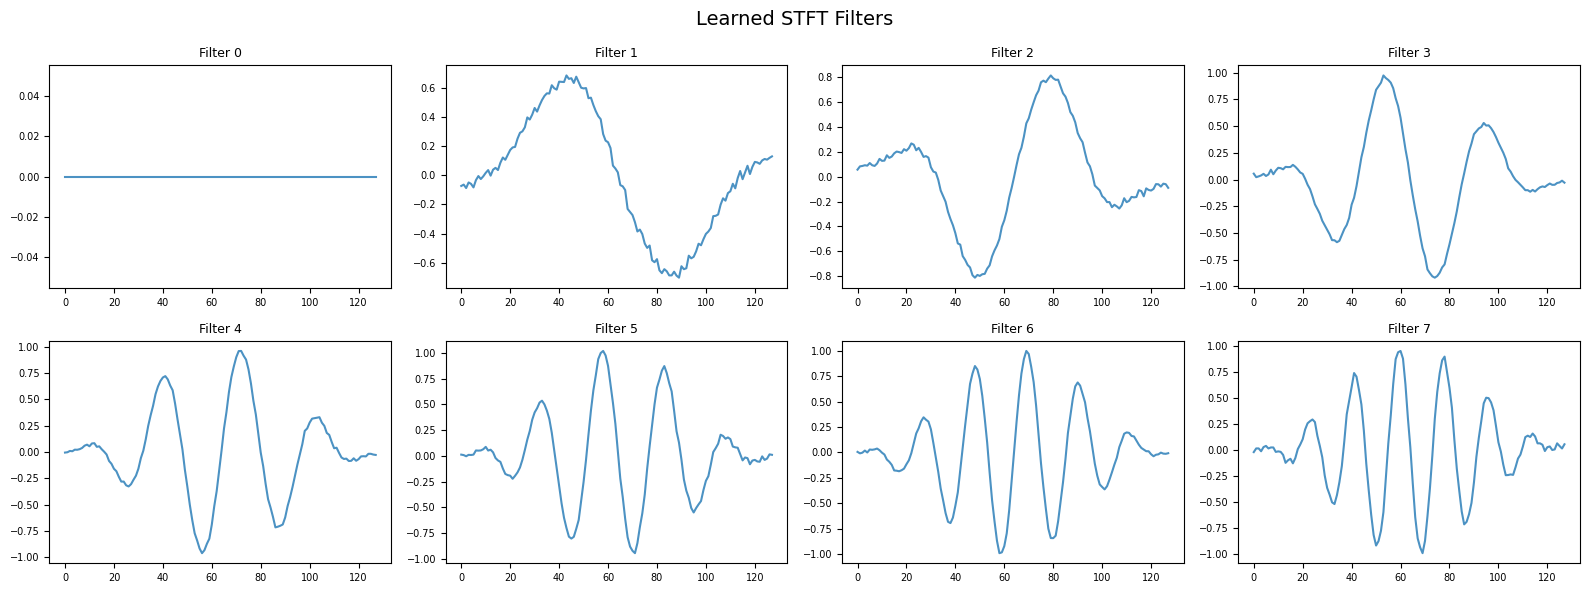

In [52]:
if CFG.trainable_stft:
    try:
        # Visualize learned vs initial STFT kernels
        learned = model.stft.wsin.detach().cpu().numpy()
        print(f"STFT kernel shape: {learned.shape}")

        fig, axes = plt.subplots(2, 4, figsize=(16, 6))
        for i, ax in enumerate(axes.flat):
            if i < min(8, learned.shape[0]):
                ax.plot(learned[i, 0, :], alpha=0.8)
                ax.set_title(f"Filter {i}", fontsize=9)
                ax.tick_params(labelsize=7)
        plt.suptitle("Learned STFT Filters", fontsize=14)
        plt.tight_layout()
        plt.show()
    except AttributeError as e:
        print(f"Could not extract STFT params: {e}")
        print("nnAudio version may use different attribute names.")

# 📌 | Reference
* [HMS-HBAC: ResNet34d Baseline [Training]](https://www.kaggle.com/code/ttahara/hms-hbac-resnet34d-baseline-training)
* [EfficientNetB2 Starter - [LB 0.57]](https://www.kaggle.com/code/cdeotte/efficientnetb2-starter-lb-0-57)
* [nnAudio Documentation](https://kinwaicheuk.github.io/nnAudio/)
* [timm Model Zoo](https://huggingface.co/timm)